In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.linear_model import LinearRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import statsmodels.api as sm
from utils import functions

dirpath = '/Users/kimchm/Documents/KimNiNature2024/MatConverted2Python/' 
metadata = pd.read_csv(dirpath + 'EDF10d_info_2026_01_16.csv')
CDdotprod_python = pd.read_csv('CDdotprod_python_deconvolved.txt')


# Compare CD dot products of CK and JH
metadata['Merged_ID'] = (
    metadata['Mouse ID'].str.strip("'") + '_' + 
    metadata['FOV'].str.strip("'") + '_' + 
    metadata['Session1'].str.strip("'").str.replace("-", "_") + '_' + 
    metadata['Session2'].str.strip("'").str.replace("-", "_")
)
cols = ['Merged_ID'] + [c for c in metadata.columns if c != 'Merged_ID']
metadata = metadata[cols]
metadata = metadata.sort_values(by='Merged_ID')
metadata = metadata.reset_index(drop=True)

filtered_CDdotprod_python = CDdotprod_python[CDdotprod_python['ID'].isin(metadata['Merged_ID'])].reset_index(drop=True)

is_aligned = metadata['Merged_ID'].equals(filtered_CDdotprod_python['ID'])
    
# sort by relearns speed
colname_relearn_speed = 'Relative trials to reach\n75% performance'
relearn_speed = metadata[colname_relearn_speed]
sorted_indices_by_relearn_speed = np.argsort(relearn_speed)

# sort by CD dot product
colname_CDdotproduct = 'CDdotproduct'
CDdotproduct = filtered_CDdotprod_python[colname_CDdotproduct]
sorted_indices_by_CDdotproduct = np.argsort(CDdotproduct)
# filtered_CDdotprod_sorted = filtered_CDdotprod_python.sort_values(by='CDdotproduct').reset_index(drop=True)

tsample   = 1.57
tdelay    = 2.87
tresponse = 4.17
dt        = 1/6
ntimestep = 47
tvec      = dt * np.arange(ntimestep)
tix_sample   = np.where(tvec > tsample)[0][0]
tix_delay    = np.where(tvec > tdelay)[0][0]
tix_response = np.where(tvec > tresponse)[0][0]
lickright    = 0
lickleft     = 1


In [2]:
# #--- sorted by relearn speed ---#
# fidx     = sorted_indices_by_relearn_speed[ix]    
# filename = filtered_CDdotprod_python['ID'][fidx]

#--- sorted by CD dot product ---#
nfile = len(filtered_CDdotprod_python)
CD_sample_dotprod_all      = np.zeros(nfile)
CD_context_dotprod_all     = np.zeros(nfile)
CD_delay_dotprod_all       = np.zeros(nfile)
CD_sample_1_all            = np.empty(nfile,dtype=object)
CD_sample_2_all            = np.empty(nfile,dtype=object)
CD_context_P_all           = np.empty(nfile,dtype=object)
CD_context_A_all           = np.empty(nfile,dtype=object)
context_1P_all        = np.zeros((nfile,ntimestep))
context_1A_all        = np.zeros((nfile,ntimestep))
context_2P_all        = np.zeros((nfile,ntimestep))
context_2A_all        = np.zeros((nfile,ntimestep))
sample_1P_all         = np.zeros((nfile,ntimestep))
sample_1A_all         = np.zeros((nfile,ntimestep))
sample_2P_all         = np.zeros((nfile,ntimestep))
sample_2A_all         = np.zeros((nfile,ntimestep))
distance_btw_context_P_all = np.zeros(nfile)
distance_btw_context_A_all = np.zeros(nfile)
for ix in range(nfile):
    
    print(ix)
    
    fidx = sorted_indices_by_CDdotproduct[ix]
    filename = filtered_CDdotprod_python['ID'][fidx]

    filepath = dirpath + filename + '.npy'
    data = np.load(filepath, allow_pickle=True)
    opto_sess1 = data['deconvolved'][0]
    opto_sess2 = data['deconvolved'][1]
    ncell      = opto_sess1.shape[1]

    # compute projected activity
    data_type = 'deconvolved'
    
    CD_sample_dotproduct, CD_sample_1_population, CD_sample_2_population, \
    proj_sample_1P, proj_sample_1A, proj_sample_2A, proj_sample_2P = functions.compute_CD_sample(data, data_type)
    
    CD_context_dotproduct, CD_context_P_population, CD_context_A_population, \
    proj_context_1P, proj_context_1A, proj_context_2A, proj_context_2P = functions.compute_CD_context(data, data_type)

    CD_delay_dotproduct, CD_delay_1_population, CD_delay_2_population, \
    _, _, _, _,\
    _, _, _, _ = functions.compute_CD_projection(data, data_type)

    sample_1P         = np.mean(proj_sample_1P,axis=1)
    sample_2P         = np.mean(proj_sample_2P,axis=1)
    sample_1A         = np.mean(proj_sample_1A,axis=1)
    sample_2A         = np.mean(proj_sample_2A,axis=1)
    context_1P        = np.mean(proj_context_1P,axis=1)
    context_2P        = np.mean(proj_context_2P,axis=1)
    context_1A        = np.mean(proj_context_1A,axis=1)
    context_2A        = np.mean(proj_context_2A,axis=1)
    distance_btw_context_P = np.mean((context_1P - context_2P)[tix_sample:tix_sample+5])
    distance_btw_context_A = np.mean((context_1A - context_2A)[tix_sample:tix_sample+5])
    
    CD_sample_dotprod_all[ix]      = CD_sample_dotproduct
    CD_context_dotprod_all[ix]     = CD_context_dotproduct
    CD_delay_dotprod_all[ix]       = CD_delay_dotproduct
    CD_sample_1_all[ix]            = CD_sample_1_population
    CD_sample_2_all[ix]            = CD_sample_2_population
    CD_context_P_all[ix]           = CD_context_P_population
    CD_context_A_all[ix]           = CD_context_A_population
    sample_1P_all[ix]              = sample_1P
    sample_1A_all[ix]              = sample_1A
    sample_2P_all[ix]              = sample_2P
    sample_2A_all[ix]              = sample_2A
    context_1P_all[ix]             = context_1P
    context_1A_all[ix]             = context_1A
    context_2P_all[ix]             = context_2P
    context_2A_all[ix]             = context_2A
    distance_btw_context_P_all[ix] = distance_btw_context_P
    distance_btw_context_A_all[ix] = distance_btw_context_A


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32


In [3]:
mean_context_1P = np.mean(context_1P_all[:,tix_sample:tix_sample+5], axis=1)
mean_context_1A = np.mean(context_1A_all[:,tix_sample:tix_sample+5], axis=1)
mean_context_2P = np.mean(context_2P_all[:,tix_sample:tix_sample+5], axis=1)
mean_context_2A = np.mean(context_2A_all[:,tix_sample:tix_sample+5], axis=1)
mean_sample_1P = np.mean(sample_1P_all[:,tix_sample:tix_sample+5], axis=1)
mean_sample_1A = np.mean(sample_1A_all[:,tix_sample:tix_sample+5], axis=1)
mean_sample_2P = np.mean(sample_2P_all[:,tix_sample:tix_sample+5], axis=1)
mean_sample_2A = np.mean(sample_2A_all[:,tix_sample:tix_sample+5], axis=1)

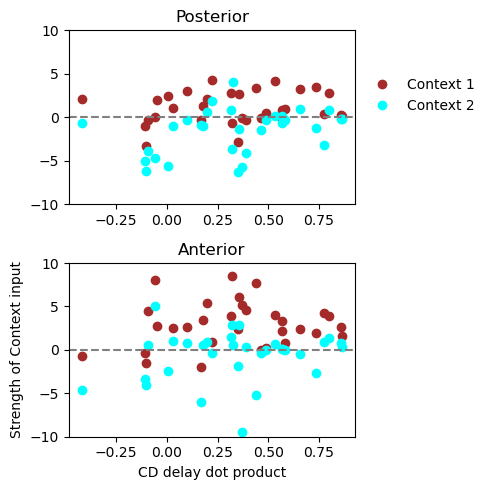

In [63]:
plt.figure(figsize=(5,5))
plt.subplot(211)
plt.title('Posterior')
plt.plot(CD_delay_dotprod_all, mean_context_1P, marker='o', c='brown', linestyle='', label='Context 1')
plt.plot(CD_delay_dotprod_all, mean_context_2P, marker='o', c='cyan', linestyle='', label='Context 2')
plt.axhline(0, color='gray', linestyle='--')
plt.legend(frameon=False, bbox_to_anchor=[1,0.8])
plt.ylim([-10,10])
plt.subplot(212)
plt.title('Anterior')
plt.plot(CD_delay_dotprod_all, mean_context_1A, marker='o', c='brown', linestyle='', label='Context 1')
plt.plot(CD_delay_dotprod_all, mean_context_2A, marker='o', c='cyan', linestyle='', label='Context 2')
plt.axhline(0, color='gray', linestyle='--')
plt.ylim([-10,10])
plt.xlabel('CD delay dot product')
plt.ylabel('Strength of Context input')
plt.tight_layout()

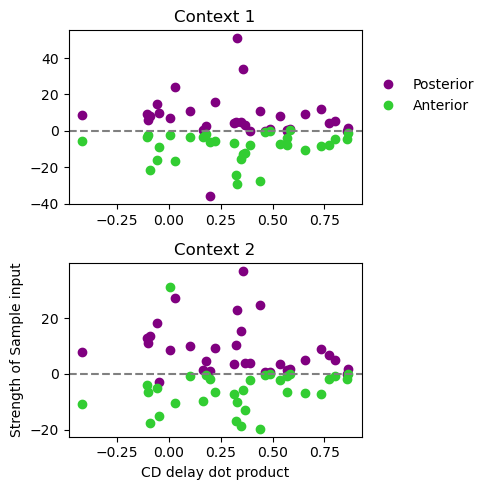

In [56]:
plt.figure(figsize=(5,5))
plt.subplot(211)
plt.title('Context 1')
plt.plot(CD_delay_dotprod_all, mean_sample_1P, marker='o', c='purple', linestyle='', label='Posterior')
plt.plot(CD_delay_dotprod_all, mean_sample_1A, marker='o', c='limegreen', linestyle='', label='Anterior')
plt.axhline(0, color='gray', linestyle='--')
plt.legend(frameon=False, bbox_to_anchor=[1,0.8])
plt.subplot(212)
plt.title('Context 2')
plt.plot(CD_delay_dotprod_all, mean_sample_2P, marker='o', c='purple', linestyle='', label='Context 1')
plt.plot(CD_delay_dotprod_all, mean_sample_2A, marker='o', c='limegreen', linestyle='', label='Context 2')
plt.axhline(0, color='gray', linestyle='--')
# plt.legend(frameon=False)
plt.xlabel('CD delay dot product')
plt.ylabel('Strength of Sample input')
plt.tight_layout()

In [6]:
CD_dotprod_1P = np.zeros(nfile)
CD_dotprod_1A = np.zeros(nfile)
CD_dotprod_2P = np.zeros(nfile)
CD_dotprod_2A = np.zeros(nfile)
CD_dotprod_12 = np.zeros(nfile)
CD_dotprod_PA = np.zeros(nfile)
for ix in range(nfile):
    CD_dotprod_1P[ix] = functions.cosine_similarity(CD_sample_1_all[ix],CD_context_P_all[ix])
    CD_dotprod_1A[ix] = functions.cosine_similarity(CD_sample_1_all[ix],CD_context_A_all[ix])
    CD_dotprod_2P[ix] = functions.cosine_similarity(CD_sample_2_all[ix],CD_context_P_all[ix])
    CD_dotprod_2A[ix] = functions.cosine_similarity(CD_sample_2_all[ix],CD_context_A_all[ix])
    CD_dotprod_12[ix] = functions.cosine_similarity(CD_sample_1_all[ix],CD_sample_2_all[ix])
    CD_dotprod_PA[ix] = functions.cosine_similarity(CD_context_P_all[ix],CD_context_A_all[ix])
    
# CD_sample_context_dotprod

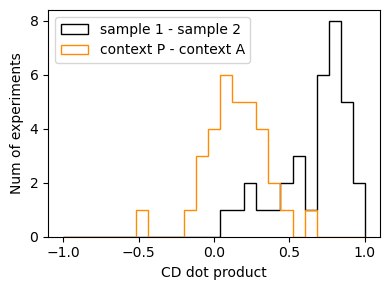

In [61]:
plt.figure(figsize=(4,3))
plt.hist(CD_dotprod_12, bins=25, range=(-1,1), histtype='step', color='k', label='sample 1 - sample 2')
plt.hist(CD_dotprod_PA, bins=25, range=(-1,1), histtype='step', color='darkorange', label='context P - context A')
plt.xlabel('CD dot product')
plt.ylabel('Num of experiments')
plt.legend()
plt.tight_layout()

In [ ]:
pred_1P_all = np.zeros(nfile)
pred_1A_all = np.zeros(nfile)
pred_2P_all = np.zeros(nfile)
pred_2A_all = np.zeros(nfile)
for ix in range(nfile):
    
    print(ix)
    
    fidx = sorted_indices_by_CDdotproduct[ix]
    filename = filtered_CDdotprod_python['ID'][fidx]
    filepath = dirpath + filename + '.npy'
    data = np.load(filepath, allow_pickle=True)
    data_type = 'deconvolved'

    pred_1P_all[ix], pred_1A_all[ix], pred_2P_all[ix], pred_2A_all[ix] = functions.decode_context(data,data_type)
    


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32


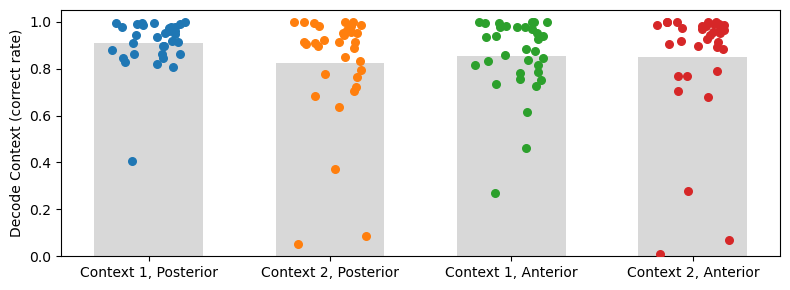

In [42]:
x = np.array([0,1,2,3])
means = np.array([np.mean(pred_1P_all), np.mean(pred_2P_all), np.mean(pred_1A_all), np.mean(pred_2A_all)])
plt.figure(figsize=(8,3))
# fig, ax = plt.subplots()
plt.bar(x, means, width=0.6, alpha=0.3, color='gray')
jitter = np.random.uniform(-0.2, 0.2, size=nfile)
plt.scatter(np.full(nfile, x[0]) + jitter, pred_1P_all, s=30, zorder=3)
plt.scatter(np.full(nfile, x[1]) + jitter, pred_2P_all, s=30, zorder=3)
plt.scatter(np.full(nfile, x[2]) + jitter, pred_1A_all, s=30, zorder=3)
plt.scatter(np.full(nfile, x[3]) + jitter, pred_2A_all, s=30, zorder=3)
plt.xticks([0,1,2,3],['Context 1, Posterior', 'Context 2, Posterior', 'Context 1, Anterior', 'Context 2, Anterior'])
plt.ylabel('Decode Context (correct rate)')
plt.tight_layout()


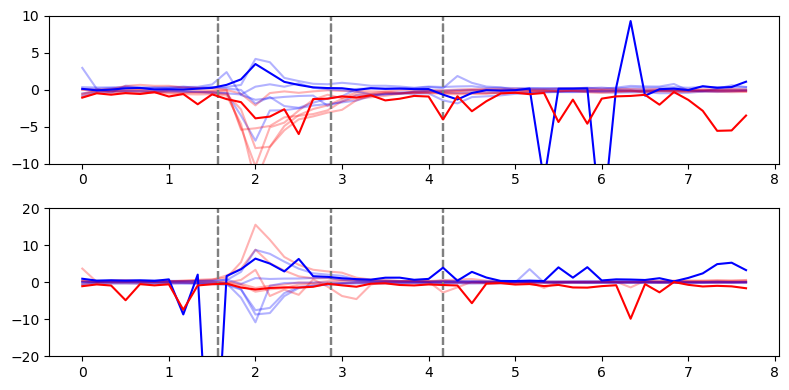

In [9]:
ntrial_plot = 5
plt.figure(figsize=(8,4))
plt.subplot(211)
for triali in range(ntrial_plot):
    plt.plot(tvec, context_1P_all[triali], c='b', alpha=0.3)
    plt.plot(tvec, context_2P_all[triali], c='r', alpha=0.3)
    plt.axvline(tsample, color='gray', linestyle='--')
    plt.axvline(tdelay, color='gray', linestyle='--')
    plt.axvline(tresponse, color='gray', linestyle='--')
plt.plot(tvec, np.mean(context_1P_all,axis=0), c='b')
plt.plot(tvec, np.mean(context_2P_all,axis=0), c='r')
plt.ylim([-10,10])

plt.subplot(212)
for triali in range(ntrial_plot):
    plt.plot(tvec, context_1A_all[triali], c='r', alpha=0.3)
    plt.plot(tvec, context_2A_all[triali], c='b', alpha=0.3)
    plt.axvline(tsample, color='gray', linestyle='--')
    plt.axvline(tdelay, color='gray', linestyle='--')
    plt.axvline(tresponse, color='gray', linestyle='--')
plt.plot(tvec, np.mean(context_1A_all,axis=0), c='b')
plt.plot(tvec, np.mean(context_2A_all,axis=0), c='r')
plt.ylim([-20,20])
plt.tight_layout()
